In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Dataset .csv")
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')


In [3]:
print("Total Restaurant Chains:", len(chains))

NameError: name 'chains' is not defined

In [4]:
chain_ratings = df.groupby("Restaurant Name")["Aggregate rating"].mean()

chain_ratings = chain_ratings.loc[chains.index]

print(chain_ratings.sort_values(ascending=False))

NameError: name 'chains' is not defined

In [5]:
restaurant_count = df["Restaurant Name"].value_counts()

print(restaurant_count.head())

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Name: count, dtype: int64


In [6]:
chains = restaurant_count[restaurant_count > 1]

print(chains)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
                    ..
San Carlo            2
Gymkhana             2
Dishoom              2
Timboo Cafe          2
D�_vero��lu          2
Name: count, Length: 734, dtype: int64


In [ ]:
chain_votes = df.groupby("Restaurant Name")["Votes"].mean()

chain_votes = chain_votes.loc[chains.index]

print(chain_votes.sort_values(ascending=False))

In [7]:
chain_analysis = df.groupby("Restaurant Name").agg(
    Outlets=("Restaurant Name","count"),
    Average_Rating=("Aggregate rating","mean"),
    Average_Votes=("Votes","mean")
)

chain_analysis = chain_analysis[chain_analysis["Outlets"] > 1]

chain_analysis = chain_analysis.sort_values(
    by="Outlets",
    ascending=False
)

print(chain_analysis.head(10))

                  Outlets  Average_Rating  Average_Votes
Restaurant Name                                         
Cafe Coffee Day        83        2.419277      29.253012
Domino's Pizza         79        2.740506      84.088608
Subway                 63        2.907937      97.206349
Green Chick Chop       51        2.672549      18.901961
McDonald's             48        3.339583     110.229167
Keventers              34        2.870588      37.147059
Pizza Hut              30        3.320000     165.366667
Giani                  29        2.689655      29.448276
Baskin Robbins         28        1.860714      15.285714
Barbeque Nation        26        4.353846    1082.384615


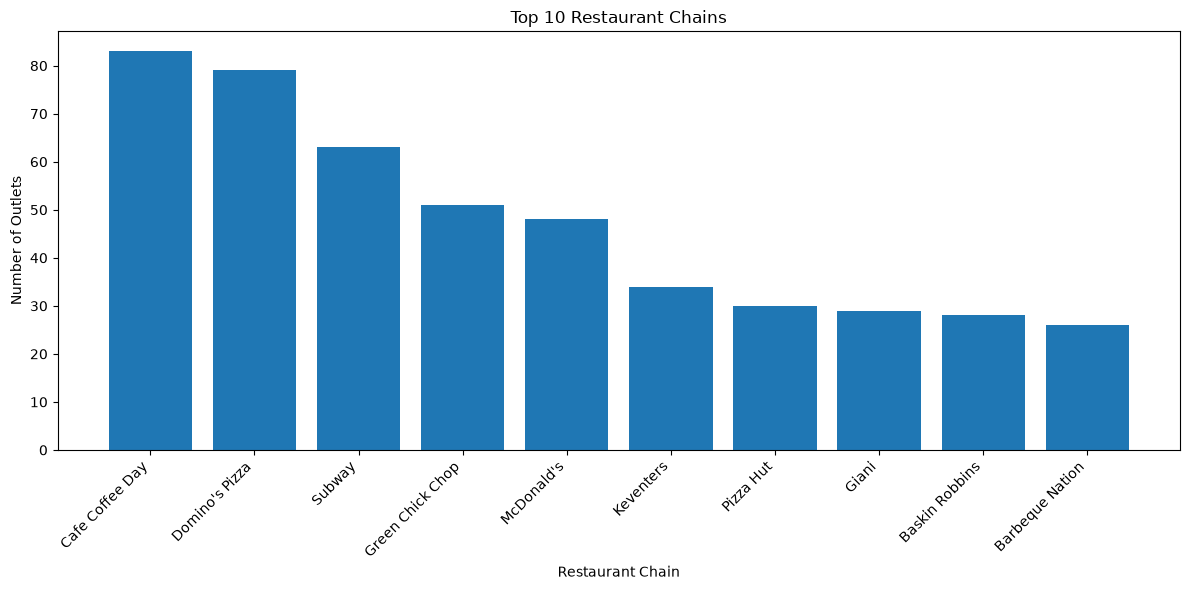

In [8]:
top10 = chain_analysis.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10.index, top10["Outlets"])

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.tight_layout()

plt.savefig("Restaurant_Chains.png")

plt.show()

In [ ]:
highest_rated = chain_analysis.sort_values(
    by="Average_Rating",
    ascending=False
)

print(highest_rated.head(10))

In [ ]:
most_popular = chain_analysis.sort_values(
    by="Average_Votes",
    ascending=False
)

print(most_popular.head(10))